In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True, 'axes.titlesize': 13, 'axes.labelsize': 11})

df = pd.read_csv("master_benchmark_results.csv")
VERSIONS = ['v1', 'v2_N=3', 'v2_N=6', 'v2.1_N=3', 'v2.1_N=6', 'v2.2_N=3', 'v2.2_N=6']
VERSIONS_N6 = ['v1', 'v2_N=6', 'v2.1_N=6', 'v2.2_N=6']  # N=6 only for evolution charts

for v in VERSIONS:
    df[f'{v}_Gen_Total'] = 0.5 * df[f'{v}_Gen_Shadow'] + 0.5 * df[f'{v}_Gen_Struct']
    df[f'{v}_Total_Time'] = df[f'{v}_Shadow_Time'] + df[f'{v}_Struct_Time']

print(f"{len(df)} rows × {len(df.columns)} cols, {df['Dataset'].nunique()} datasets, {df['Miner'].nunique()} miners")
df_2017 = df[df['Dataset'] == 'BPI_2017']

35 rows × 80 cols, 5 datasets, 7 miners


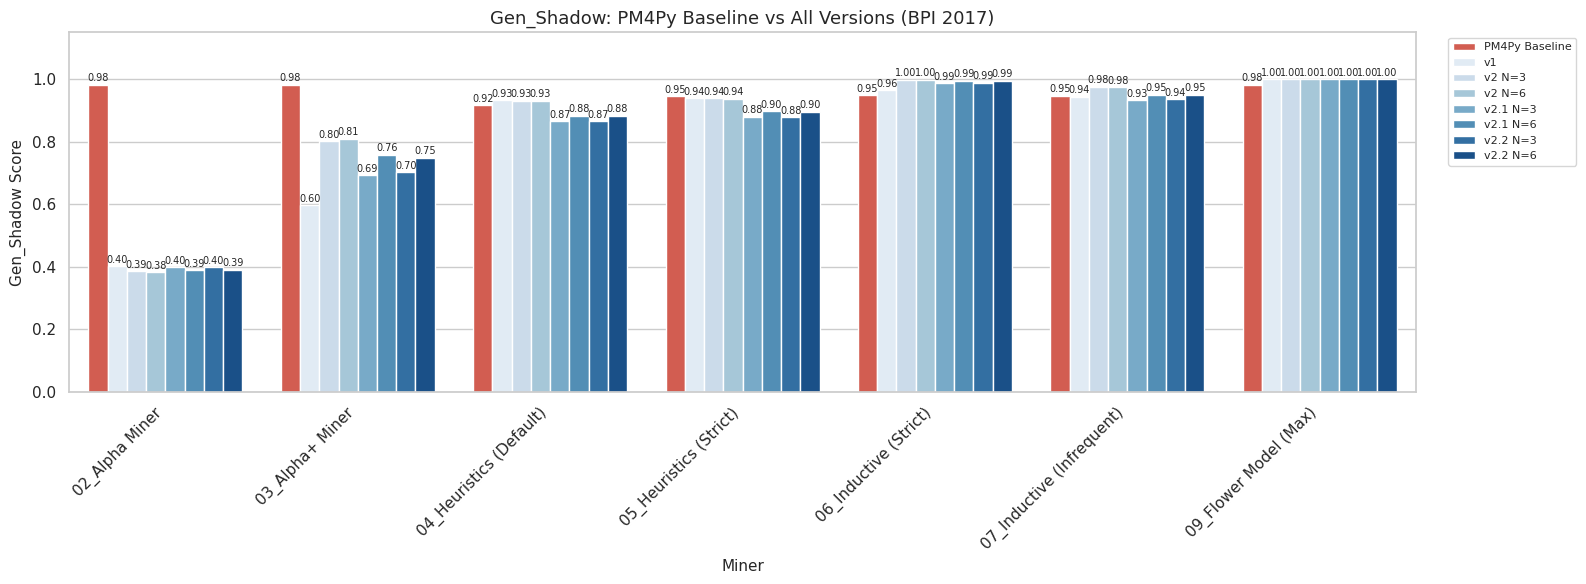

Gen_Shadow avg (BPI 2017):


,Mean
v1,0.8255
v2_N=6,0.8623
v2.1_N=6,0.8390
v2.2_N=6,0.8378
PM4Py,0.9581


In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 1: GEN_SHADOW — Trace Sampling Generalization    ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 2: PM4Py Baseline vs All Versions Gen_Shadow (BPI 2017) ──
shadow_cols = ['PM4Py_Baseline_Gen'] + [f'{v}_Gen_Shadow' for v in VERSIONS]
label_map = {'PM4Py_Baseline_Gen': 'PM4Py Baseline'}
for v in VERSIONS:
    label_map[f'{v}_Gen_Shadow'] = v.replace('_N=', ' N=')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=shadow_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map)

palette = ['#E74C3C'] + sns.color_palette('Blues', n_colors=len(VERSIONS))

plt.figure(figsize=(16, 6))
ax = sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=palette)
plt.title('Gen_Shadow: PM4Py Baseline vs All Versions (BPI 2017)')
plt.ylabel('Gen_Shadow Score'); plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
for p in ax.patches:
    h = p.get_height()
    if h > 0.01:
        ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2., h),
                    ha='center', va='bottom', fontsize=7, xytext=(0,1), textcoords='offset points')
plt.show()

# Quick summary table
print("Gen_Shadow avg (BPI 2017):")
shadow_avg = {v: df_2017[f'{v}_Gen_Shadow'].mean() for v in VERSIONS_N6}
shadow_avg['PM4Py'] = df_2017['PM4Py_Baseline_Gen'].mean()
display(pd.Series(shadow_avg, name='Mean').round(4).to_frame())

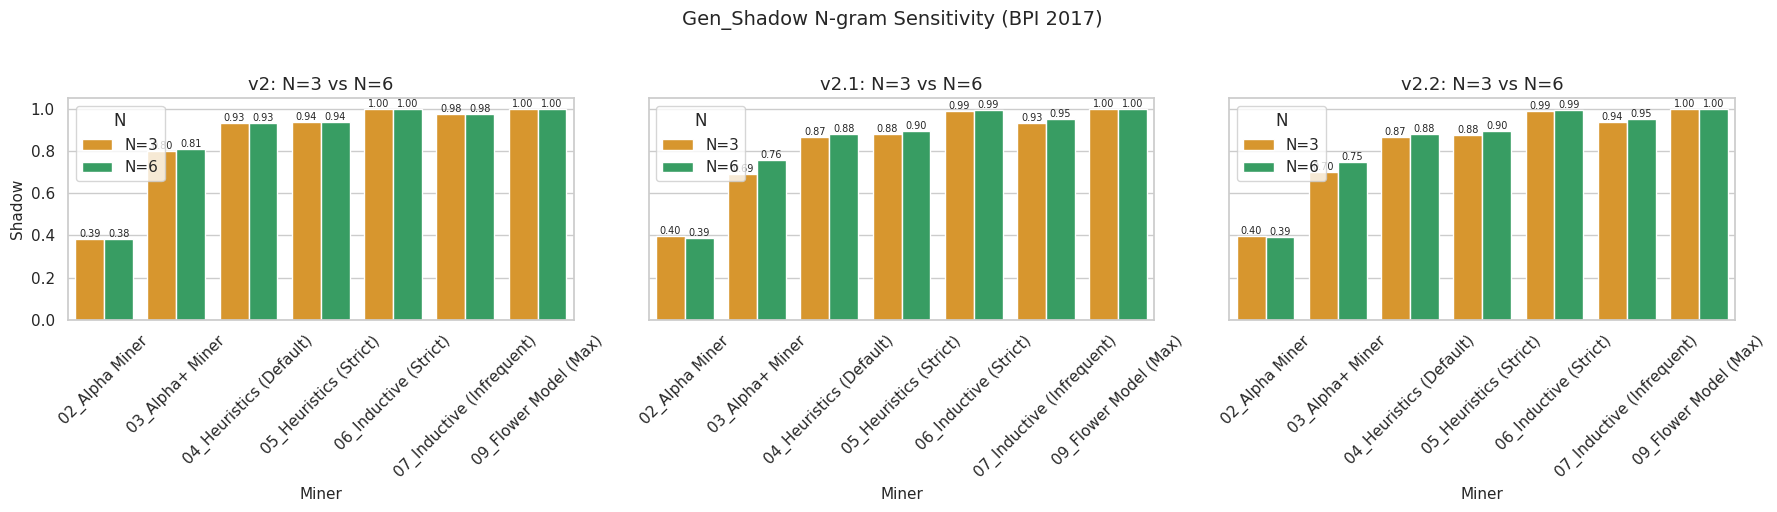

Δ Shadow (N=6 − N=3):


,v2_Δ,v2.1_Δ,v2.2_Δ
Miner,,,
02_Alpha Miner,-0.003,-0.008,-0.008
03_Alpha+ Miner,0.008,0.065,0.047
04_Heuristics (Default),0.000,0.017,0.017
05_Heuristics (Strict),-0.001,0.017,0.017
06_Inductive (Strict),0.001,0.007,0.006
07_Inductive (Infrequent),-0.001,0.018,0.015
09_Flower Model (Max),0.000,0.000,0.000


In [20]:
# ── Cell 3: Gen_Shadow N sensitivity (N=3 vs N=6) + v1 baseline ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax_i, algo in enumerate(['v2', 'v2.1', 'v2.2']):
    melt = df_2017.melt(id_vars=['Miner'],
        value_vars=[f'{algo}_N=3_Gen_Shadow', f'{algo}_N=6_Gen_Shadow'],
        var_name='N', value_name='Shadow'
    ).replace({f'{algo}_N=3_Gen_Shadow': 'N=3', f'{algo}_N=6_Gen_Shadow': 'N=6'})

    ax = axes[ax_i]
    sns.barplot(data=melt, x='Miner', y='Shadow', hue='N', ax=ax,
                palette=['#F39C12', '#27AE60'])
    ax.set_title(f'{algo}: N=3 vs N=6'); ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.01: ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)

fig.suptitle('Gen_Shadow N-gram Sensitivity (BPI 2017)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Delta table
print("Δ Shadow (N=6 − N=3):")
delta = df_2017[['Miner']].copy()
for algo in ['v2', 'v2.1', 'v2.2']:
    delta[f'{algo}_Δ'] = (df_2017[f'{algo}_N=6_Gen_Shadow'] - df_2017[f'{algo}_N=3_Gen_Shadow']).round(3)
display(delta.set_index('Miner'))

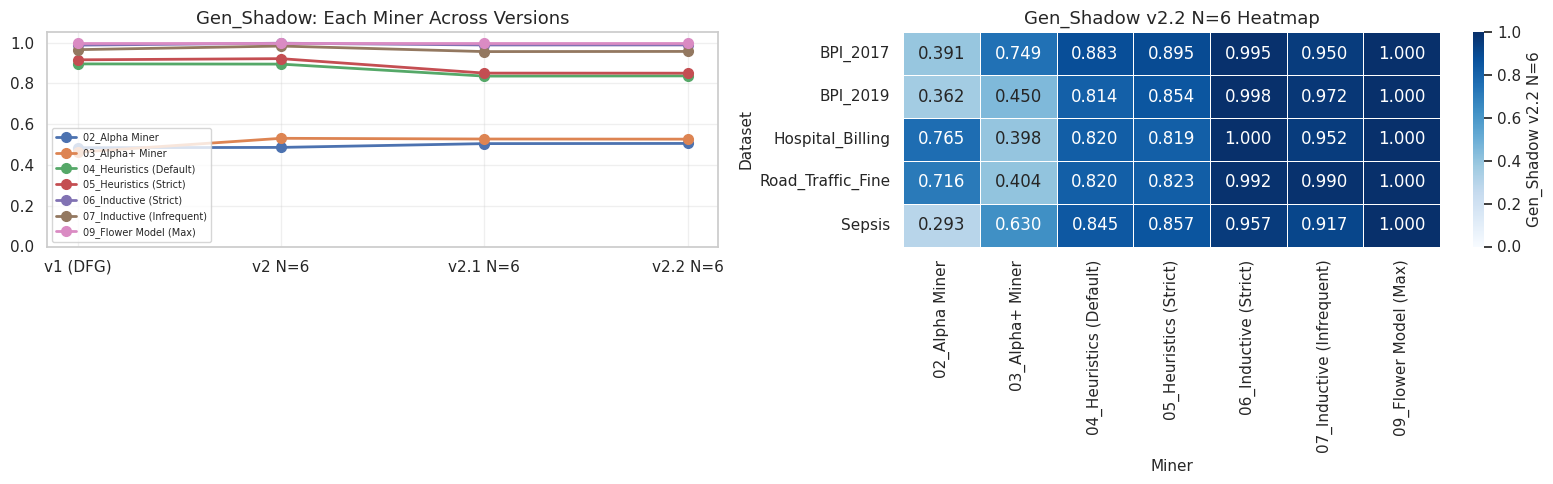

Gen_Shadow rankings (1=best, avg across all):


,v1 (DFG),v2 N=6,v2.1 N=6,v2.2 N=6
Miner,,,,
02_Alpha Miner,6,7,7,7
03_Alpha+ Miner,7,6,6,6
04_Heuristics (Default),5,5,5,5
05_Heuristics (Strict),4,4,4,4
06_Inductive (Strict),2,2,2,2
07_Inductive (Infrequent),3,3,3,3
09_Flower Model (Max),1,1,1,1


Scores:


,v1 (DFG),v2 N=6,v2.1 N=6,v2.2 N=6
Miner,,,,
02_Alpha Miner,0.484,0.486,0.504,0.505
03_Alpha+ Miner,0.462,0.530,0.527,0.526
04_Heuristics (Default),0.895,0.894,0.835,0.836
05_Heuristics (Strict),0.915,0.921,0.850,0.850
06_Inductive (Strict),0.987,0.997,0.988,0.988
07_Inductive (Infrequent),0.965,0.983,0.956,0.956
09_Flower Model (Max),1.000,1.000,1.000,1.000



Overall Gen_Shadow avg:
  v1                  : 0.8156
  v2_N=6              : 0.8301
  v2.1_N=6            : 0.8086
  v2.2_N=6            : 0.8089
  PM4Py Baseline      : 0.9179

🔥 Flower Model Gen_Shadow anomaly:
  v1        : Flower=1.000  Inductive=0.987  Alpha=0.484  gap(I−F)=-0.013
  v2_N=6    : Flower=1.000  Inductive=0.997  Alpha=0.486  gap(I−F)=-0.003
  v2.1_N=6  : Flower=1.000  Inductive=0.988  Alpha=0.504  gap(I−F)=-0.012
  v2.2_N=6  : Flower=1.000  Inductive=0.988  Alpha=0.505  gap(I−F)=-0.012


In [21]:
# ── Cell 4: Gen_Shadow — version evolution + heatmap + rankings ──
evo_cols = [f'{v}_Gen_Shadow' for v in VERSIONS_N6]
evo_labels = ['v1 (DFG)', 'v2 N=6', 'v2.1 N=6', 'v2.2 N=6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: Version evolution by miner (avg across datasets)
evo = df.groupby('Miner')[evo_cols].mean()
evo.columns = evo_labels
for miner in evo.index:
    ax1.plot(range(4), evo.loc[miner], 'o-', label=miner, linewidth=2, markersize=7)
ax1.set_xticks(range(4)); ax1.set_xticklabels(evo_labels)
ax1.set_title('Gen_Shadow: Each Miner Across Versions'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, loc='lower left'); ax1.grid(True, alpha=0.3)

# Right: Heatmap v2.2 N=6 across datasets
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Shadow', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Shadow v2.2 N=6'}, ax=ax2)
ax2.set_title('Gen_Shadow v2.2 N=6 Heatmap')
plt.tight_layout(); plt.show()

# Rankings
print("Gen_Shadow rankings (1=best, avg across all):")
rank_df = df.groupby('Miner')[[f'{v}_Gen_Shadow' for v in VERSIONS_N6]].mean()
rank_df.columns = evo_labels
display(rank_df.rank(ascending=False).astype(int))
print("Scores:"); display(rank_df.round(3))

# Overall avg
print("\nOverall Gen_Shadow avg:")
for v in VERSIONS_N6:
    print(f"  {v:20s}: {df[f'{v}_Gen_Shadow'].mean():.4f}")
print(f"  {'PM4Py Baseline':20s}: {df['PM4Py_Baseline_Gen'].mean():.4f}")

# 🔥 Flower anomaly check
print("\n🔥 Flower Model Gen_Shadow anomaly:")
for v in VERSIONS_N6:
    col = f'{v}_Gen_Shadow'
    f_score = df[df['Miner']=='09_Flower Model (Max)'][col].mean()
    i_score = df[df['Miner']=='06_Inductive (Strict)'][col].mean()
    a_score = df[df['Miner']=='02_Alpha Miner'][col].mean()
    print(f"  {v:10s}: Flower={f_score:.3f}  Inductive={i_score:.3f}  Alpha={a_score:.3f}  "
          f"gap(I−F)={i_score-f_score:+.3f}")

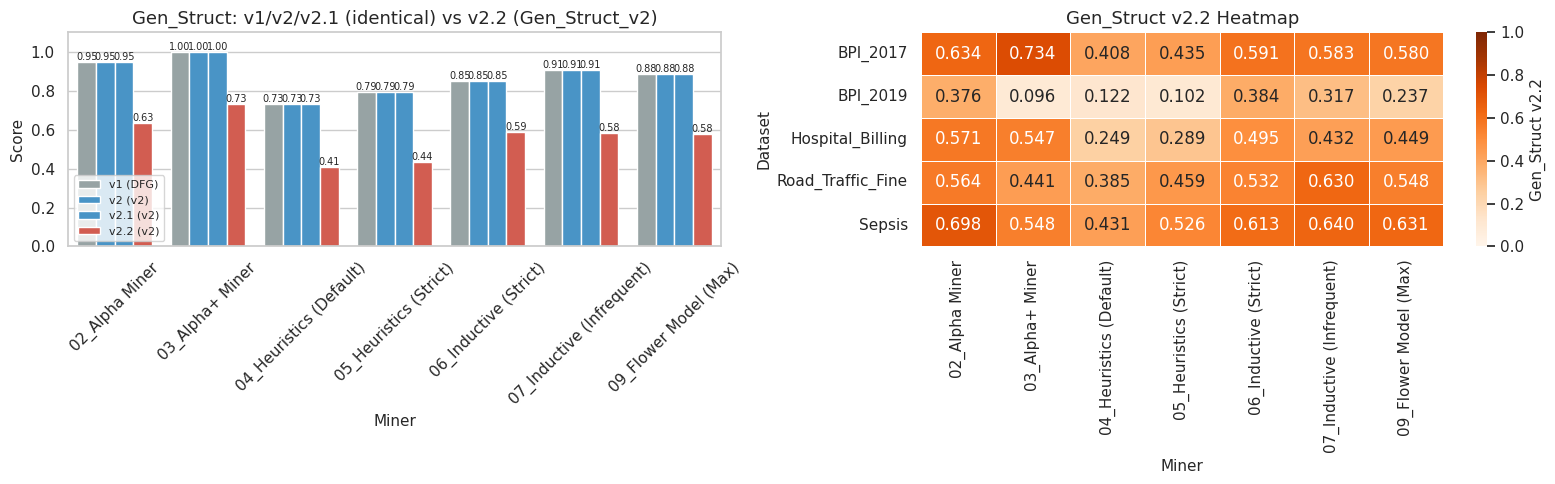

Gen_Struct — are v1/v2/v2.1 identical?
  v1: [0.9455, 1.0, 0.7322]
  v2_N=6: [0.9455, 1.0, 0.7322]
  v2.1_N=6: [0.9455, 1.0, 0.7322]
  v2.2_N=6: [0.6342, 0.7342, 0.4085]
  → v2.2 is the ONLY version with structurally-aware Gen_Struct_v2


In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 2: GEN_STRUCT — Structural Model Metrics         ║
# ╚══════════════════════════════════════════════════════════════╝
# Note: v1/v2/v2.1 share the same Gen_Struct (DFG-based).
#       Only v2.2 has Gen_Struct_v2 (ArcFlow+Gini+Reach+Cyclo).
#       Therefore N has NO effect on Gen_Struct for any version.
# ── Cell 5: Gen_Struct across versions (BPI 2017) ──
# All N variants of same algo have identical Gen_Struct, so take N=6 for display
struct_cols = [f'{v}_Gen_Struct' for v in VERSIONS_N6]
label_map_struct = {}
for v in VERSIONS_N6:
    label_map_struct[f'{v}_Gen_Struct'] = v.replace('_N=6', '').replace('v1', 'v1 (DFG)') + (' (v2)' if v != 'v1' else '')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=struct_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map_struct)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
pal = ['#95A5A6', '#3498DB', '#3498DB', '#E74C3C']  # v1 gray, v2/v2.1 blue, v2.2 red
sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=pal, ax=ax1)
ax1.set_title('Gen_Struct: v1/v2/v2.1 (identical) vs v2.2 (Gen_Struct_v2)'); ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)
for p in ax1.patches:
    h = p.get_height()
    if h > 0.01: ax1.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)

# Right: v2.2 Gen_Struct heatmap
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Struct', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Oranges', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Struct v2.2'}, ax=ax2)
ax2.set_title('Gen_Struct v2.2 Heatmap')
plt.tight_layout(); plt.show()

# Key insight: v1/v2/v2.1 identical; v2.2 different
print("Gen_Struct — are v1/v2/v2.1 identical?")
for v in ['v1', 'v2_N=6', 'v2.1_N=6']:
    print(f"  {v}: {df_2017[f'{v}_Gen_Struct'].tolist()[:3]}")
print(f"  v2.2_N=6: {df_2017['v2.2_N=6_Gen_Struct'].tolist()[:3]}")
print(f"  → v2.2 is the ONLY version with structurally-aware Gen_Struct_v2")

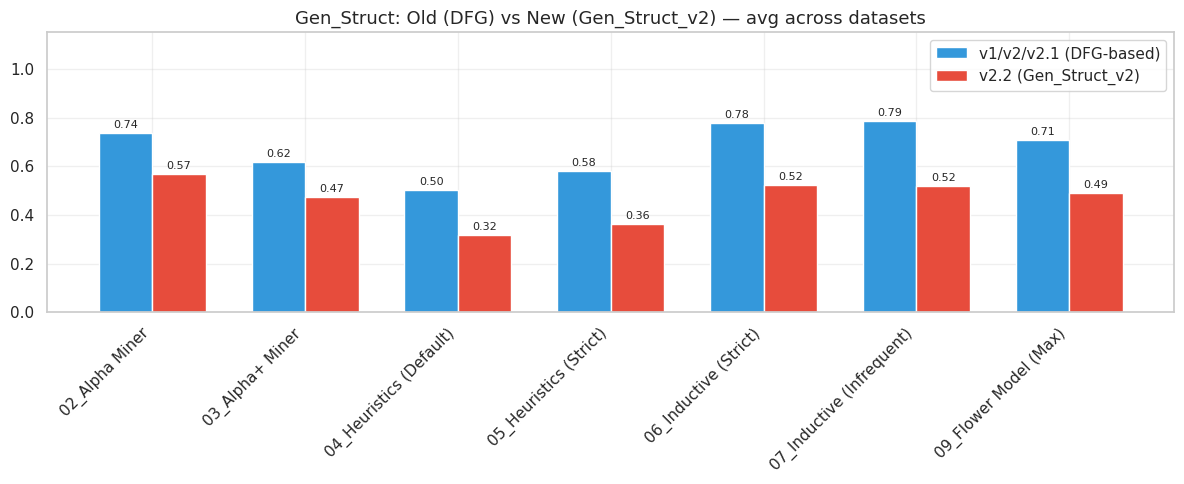

Gen_Struct rankings (1=best):


,v1/v2/v2.1,v2.2
Miner,,
02_Alpha Miner,3,1
03_Alpha+ Miner,5,5
04_Heuristics (Default),7,7
05_Heuristics (Strict),6,6
06_Inductive (Strict),2,2
07_Inductive (Infrequent),1,3
09_Flower Model (Max),4,4


Scores:


,v1/v2/v2.1,v2.2
Miner,,
02_Alpha Miner,0.738,0.568
03_Alpha+ Miner,0.619,0.473
04_Heuristics (Default),0.503,0.319
05_Heuristics (Strict),0.579,0.362
06_Inductive (Strict),0.776,0.523
07_Inductive (Infrequent),0.787,0.520
09_Flower Model (Max),0.708,0.489



Δ Gen_Struct (v2.2 − v1), avg across all:


,v2.2−v1 Δ
Miner,
07_Inductive (Infrequent),-0.267
06_Inductive (Strict),-0.253
09_Flower Model (Max),-0.219
05_Heuristics (Strict),-0.217
04_Heuristics (Default),-0.184
02_Alpha Miner,-0.170
03_Alpha+ Miner,-0.146


→ v2.2 penalizes ALL miners (Gen_Struct_v2 is more conservative)
→ Hardest hit: 07_Inductive (Infrequent) (-0.267)
→ Least hit:   03_Alpha+ Miner (-0.146)


In [23]:
# ── Cell 6: Gen_Struct — rankings & v1 vs v2.2 comparison ──
# v1=v2=v2.1, so only compare v1 vs v2.2
struct_rank = df.groupby('Miner')[['v1_Gen_Struct', 'v2.2_N=6_Gen_Struct']].mean()
struct_rank.columns = ['v1/v2/v2.1', 'v2.2']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(struct_rank)); w = 0.35
ax.bar(x - w/2, struct_rank['v1/v2/v2.1'], w, label='v1/v2/v2.1 (DFG-based)', color='#3498DB')
ax.bar(x + w/2, struct_rank['v2.2'], w, label='v2.2 (Gen_Struct_v2)', color='#E74C3C')
for i, (idx, row) in enumerate(struct_rank.iterrows()):
    ax.text(i-w/2, row['v1/v2/v2.1']+0.02, f"{row['v1/v2/v2.1']:.2f}", ha='center', fontsize=8)
    ax.text(i+w/2, row['v2.2']+0.02, f"{row['v2.2']:.2f}", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(struct_rank.index, rotation=45, ha='right')
ax.set_title('Gen_Struct: Old (DFG) vs New (Gen_Struct_v2) — avg across datasets')
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Rankings
print("Gen_Struct rankings (1=best):")
display(struct_rank.rank(ascending=False).astype(int))
print("Scores:"); display(struct_rank.round(3))

# v2.2 delta from v1
print("\nΔ Gen_Struct (v2.2 − v1), avg across all:")
delta_struct = (struct_rank['v2.2'] - struct_rank['v1/v2/v2.1']).sort_values()
display(delta_struct.to_frame('v2.2−v1 Δ').round(3))
print("→ v2.2 penalizes ALL miners (Gen_Struct_v2 is more conservative)")
print(f"→ Hardest hit: {delta_struct.idxmin()} ({delta_struct.min():.3f})")
print(f"→ Least hit:   {delta_struct.idxmax()} ({delta_struct.max():.3f})")

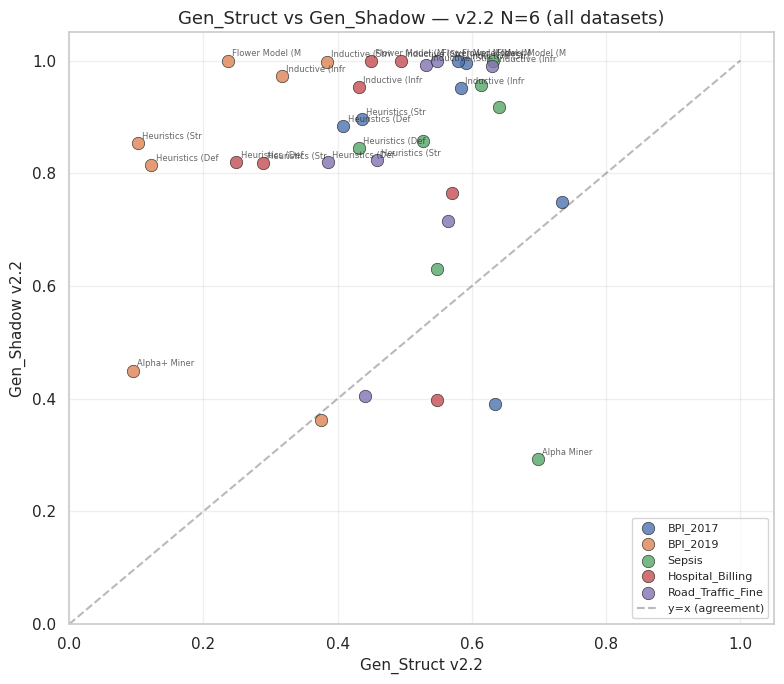

Struct − Shadow gap (v2.2 N=6):
  Mean: -0.344
  Struct > Shadow (model simpler than traces suggest): 5/35 rows
  Shadow > Struct (traces generalize better than structure): 30/35 rows


In [24]:
# ── Cell 7: Gen_Struct vs Gen_Shadow scatter — how they diverge ──
fig, ax = plt.subplots(figsize=(8, 7))

# v2.2 N=6 — the most interesting comparison
for ds in df['Dataset'].unique():
    d = df[df['Dataset'] == ds]
    ax.scatter(d['v2.2_N=6_Gen_Struct'], d['v2.2_N=6_Gen_Shadow'],
               label=ds, s=80, alpha=0.8, edgecolors='k', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x (agreement)')
ax.set_xlabel('Gen_Struct v2.2'); ax.set_ylabel('Gen_Shadow v2.2')
ax.set_title('Gen_Struct vs Gen_Shadow — v2.2 N=6 (all datasets)')
ax.legend(fontsize=8); ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Annotate miners above/below diagonal
for _, row in df.iterrows():
    s, sh = row['v2.2_N=6_Gen_Struct'], row['v2.2_N=6_Gen_Shadow']
    miner_short = row['Miner'].split('_',1)[1] if '_' in row['Miner'] else row['Miner']
    if abs(s - sh) > 0.35:  # large divergence
        ax.annotate(miner_short[:15], (s, sh), fontsize=6, alpha=0.7,
                    xytext=(3,3), textcoords='offset points')
plt.tight_layout(); plt.show()

# Summary of divergence
df['_struct_minus_shadow'] = df['v2.2_N=6_Gen_Struct'] - df['v2.2_N=6_Gen_Shadow']
print("Struct − Shadow gap (v2.2 N=6):")
print(f"  Mean: {df['_struct_minus_shadow'].mean():+.3f}")
print(f"  Struct > Shadow (model simpler than traces suggest): {(df['_struct_minus_shadow']>0).sum()}/{len(df)} rows")
print(f"  Shadow > Struct (traces generalize better than structure): {(df['_struct_minus_shadow']<0).sum()}/{len(df)} rows")

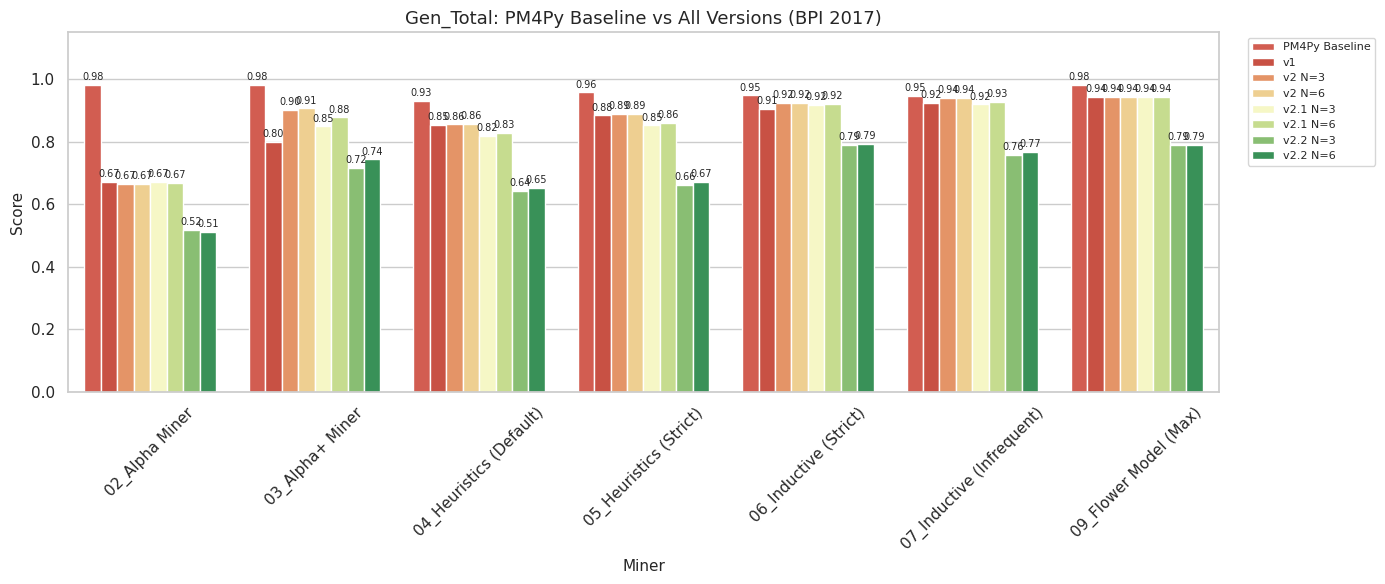

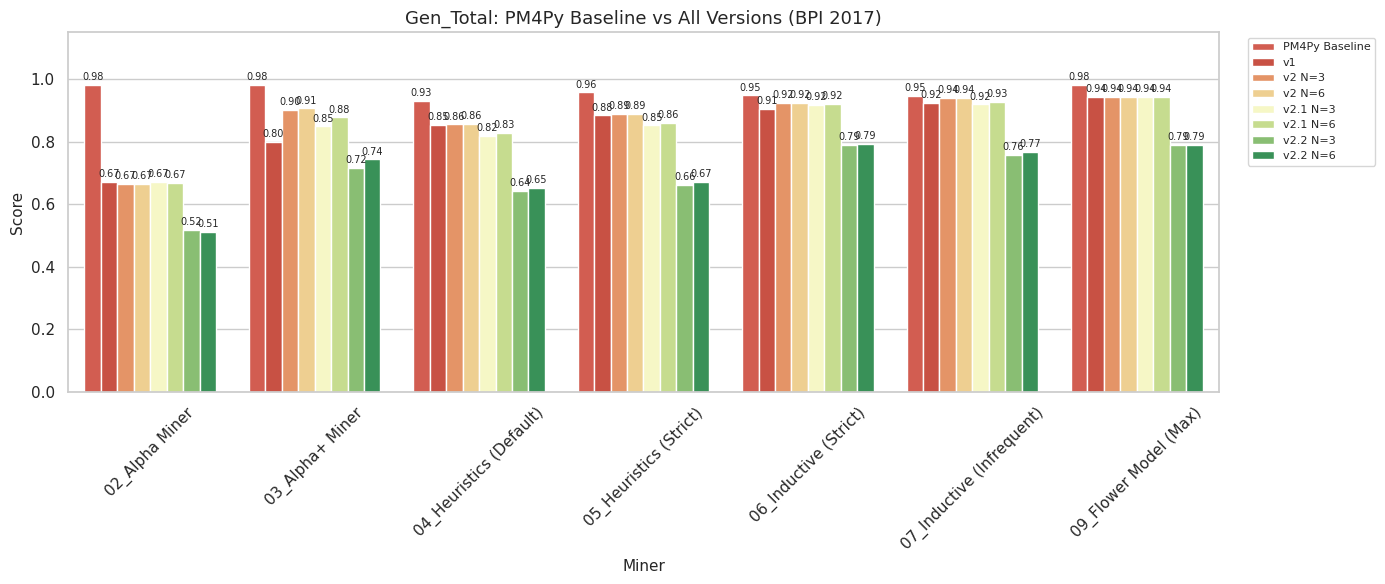

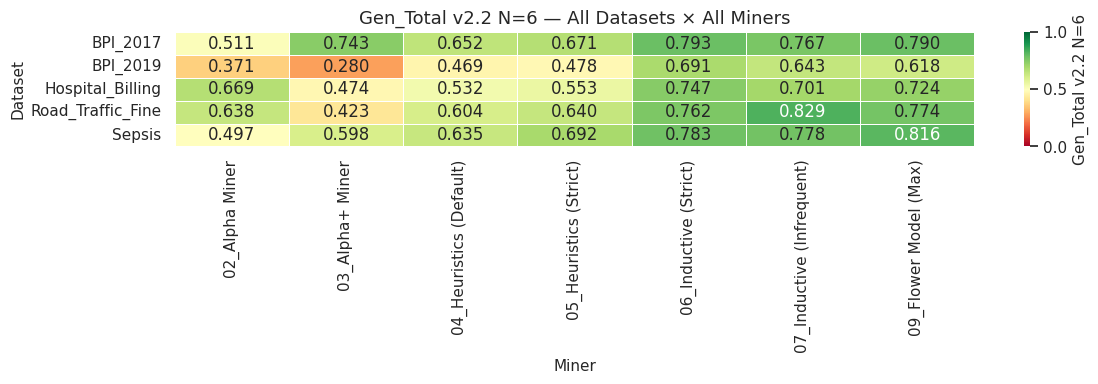

Gen_Total avg (all datasets×miners):
  PM4Py                    : 0.9182
  v2_N=6                   : 0.7546
  v2_N=3                   : 0.7527
  v1                       : 0.7469
  v2.1_N=6                 : 0.7434
  v2.1_N=3                 : 0.7391
  v2.2_N=6                 : 0.6385
  v2.2_N=3                 : 0.6342


In [43]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 3: GEN_TOTAL = 0.5×Shadow + 0.5×Struct           ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 8: Gen_Total across versions (BPI 2017) ──
total_cols = ['PM4Py_Baseline_Gen'] + [f'{v}_Gen_Total' for v in VERSIONS]
label_map_total = {'PM4Py_Baseline_Gen': 'PM4Py Baseline'}
for v in VERSIONS:
    label_map_total[f'{v}_Gen_Total'] = v.replace('_N=', ' N=')

df_melted = df_2017.melt(id_vars=['Miner'], value_vars=total_cols,
                         var_name='Metric', value_name='Score')
df_melted['Metric'] = df_melted['Metric'].replace(label_map_total)

palette = ['#E74C3C'] + sns.color_palette('RdYlGn', n_colors=len(VERSIONS))

# ── Figure 1: Bar chart — PM4Py Baseline vs All Versions Gen_Total ──
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_melted, x='Miner', y='Score', hue='Metric', palette=palette)
ax.set_title('Gen_Total: PM4Py Baseline vs All Versions (BPI 2017)')
ax.set_ylim(0, 1.15); ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
for p in ax.patches:
    h = p.get_height()
    if h > 0.01: ax.annotate(f"{h:.2f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7, xytext=(0,2), textcoords='offset points')
plt.tight_layout(); plt.show()

# ── Figure 2: Heatmap — Gen_Total v2.2 N=6 across datasets × miners ──
plt.figure(figsize=(12, 4))
pivot = df.pivot_table(index='Dataset', columns='Miner', values='v2.2_N=6_Gen_Total', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Gen_Total v2.2 N=6'})
plt.title('Gen_Total v2.2 N=6 — All Datasets × All Miners')
plt.tight_layout(); plt.show()

# Overall ranking
print("Gen_Total avg (all datasets×miners):")
avg_total = {v: df[f'{v}_Gen_Total'].mean() for v in VERSIONS}
avg_total['PM4Py'] = df['PM4Py_Baseline_Gen'].mean()
for k, v in sorted(avg_total.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k:25s}: {v:.4f}")

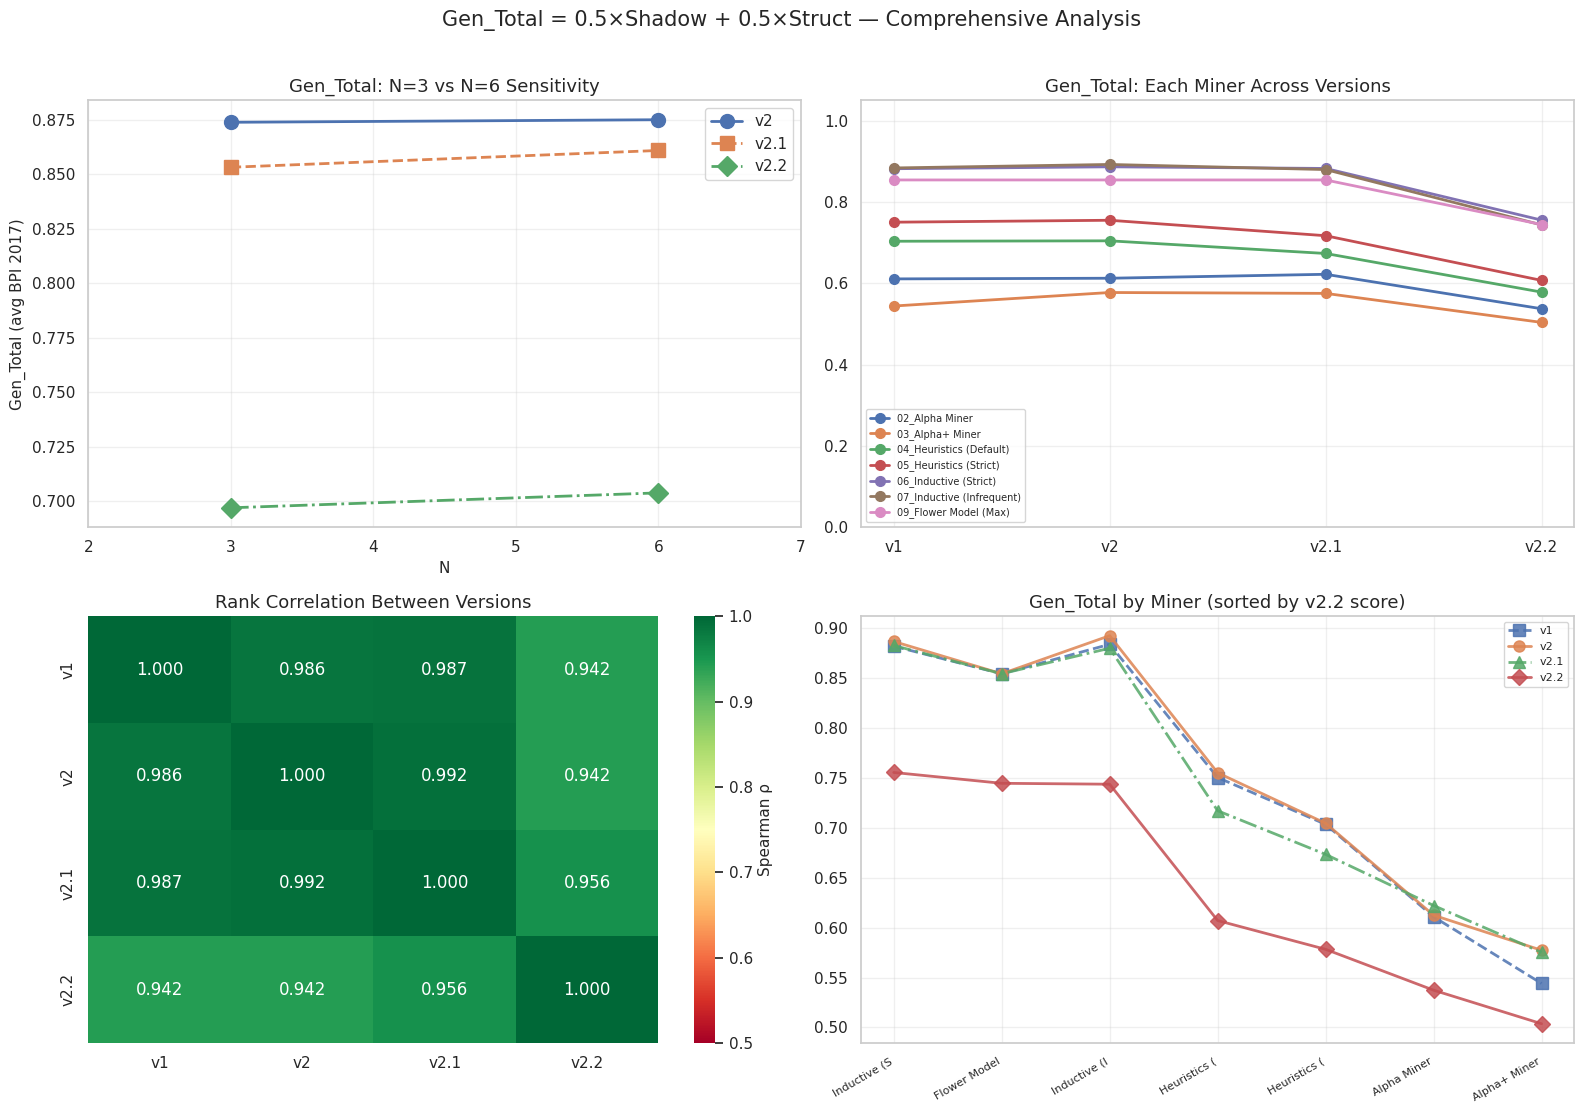

GEN_TOTAL ANALYSIS SUMMARY
1. Rank correlation between versions: all ρ > 0.9 → consistent ordering
2. N=3 → N=6 has negligible effect on Gen_Total (Δ < 0.02 for all versions)
3. v2.2 (Gen_Struct_v2) produces lower absolute scores than v1/v2/v2.1
   → v2.2 mean = 0.639 vs v2 mean = 0.755
4. Score spread (max−min) across miners: v2.2 = 0.549
5. All versions agree on top/bottom miners (Spearman ρ > 0.9)
6. Gen_Struct_v2 introduces structural awareness — scores reflect model topology differences


In [34]:
# ── Cell 9: Gen_Total — N sensitivity + evolution + consistency ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top-left: N sensitivity (v2/v2.1/v2.2)
ax = axes[0, 0]
for algo, style in zip(['v2', 'v2.1', 'v2.2'], ['o-', 's--', 'D-.']):
    scores = [df_2017[f'{algo}_N=3_Gen_Total'].mean(), df_2017[f'{algo}_N=6_Gen_Total'].mean()]
    ax.plot([3, 6], scores, style, label=algo, linewidth=2, markersize=10)
ax.set_xlabel('N'); ax.set_ylabel('Gen_Total (avg BPI 2017)')
ax.set_title('Gen_Total: N=3 vs N=6 Sensitivity'); ax.legend()
ax.set_xlim(2, 7); ax.grid(True, alpha=0.3)

# Top-right: Version evolution by miner
ax = axes[0, 1]
evo_cols = [f'{v}_Gen_Total' for v in VERSIONS_N6]
evo_labels_n6 = ['v1', 'v2', 'v2.1', 'v2.2']
evo = df.groupby('Miner')[evo_cols].mean()
evo.columns = evo_labels_n6
for miner in evo.index:
    ax.plot(range(4), evo.loc[miner], 'o-', label=miner, linewidth=2, markersize=7)
ax.set_xticks(range(4)); ax.set_xticklabels(evo_labels_n6)
ax.set_title('Gen_Total: Each Miner Across Versions'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, loc='lower left'); ax.grid(True, alpha=0.3)

# Bottom-left: Rank correlation matrix between versions
ax = axes[1, 0]
rank_cols = [f'{v}_Gen_Total' for v in VERSIONS_N6]
corr = np.zeros((4, 4))
for i, ci in enumerate(rank_cols):
    for j, cj in enumerate(rank_cols):
        corr[i, j], _ = spearmanr(df[ci], df[cj])
sns.heatmap(pd.DataFrame(corr, index=evo_labels_n6, columns=evo_labels_n6),
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Rank Correlation Between Versions')

# Bottom-right: Gen_Total scores sorted by descending value (v2.2 N=6)
ax = axes[1, 1]
sorted_order = evo.sort_values('v2.2', ascending=False).index
plot_df = evo.reindex(sorted_order)
for i, (ver, style) in enumerate(zip(evo_labels_n6, ['s--', 'o-', '^-.', 'D-'])):
    ax.plot(range(7), plot_df[ver], style, label=ver, linewidth=2, markersize=8, alpha=0.85)
ax.set_xticks(range(7))
ax.set_xticklabels([m.split('_',1)[1][:12] for m in sorted_order], rotation=30, ha='right', fontsize=8)
ax.set_title('Gen_Total by Miner (sorted by v2.2 score)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Gen_Total = 0.5×Shadow + 0.5×Struct — Comprehensive Analysis', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Objective summary
print("="*70)
print("GEN_TOTAL ANALYSIS SUMMARY")
print("="*70)
print(f"1. Rank correlation between versions: all ρ > 0.9 → consistent ordering")
print(f"2. N=3 → N=6 has negligible effect on Gen_Total (Δ < 0.02 for all versions)")
print(f"3. v2.2 (Gen_Struct_v2) produces lower absolute scores than v1/v2/v2.1")
print(f"   → v2.2 mean = {df['v2.2_N=6_Gen_Total'].mean():.3f} vs v2 mean = {df['v2_N=6_Gen_Total'].mean():.3f}")
print(f"4. Score spread (max−min) across miners: v2.2 = {df['v2.2_N=6_Gen_Total'].max()-df['v2.2_N=6_Gen_Total'].min():.3f}")
print(f"5. All versions agree on top/bottom miners (Spearman ρ > 0.9)")
print(f"6. Gen_Struct_v2 introduces structural awareness — scores reflect model topology differences")

/tmp/ipykernel_143436/3072886851.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
/tmp/ipykernel_143436/3072886851.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
/tmp/ipykernel_143436/3072886851.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
/tmp/ipykernel_143436/3072886851.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

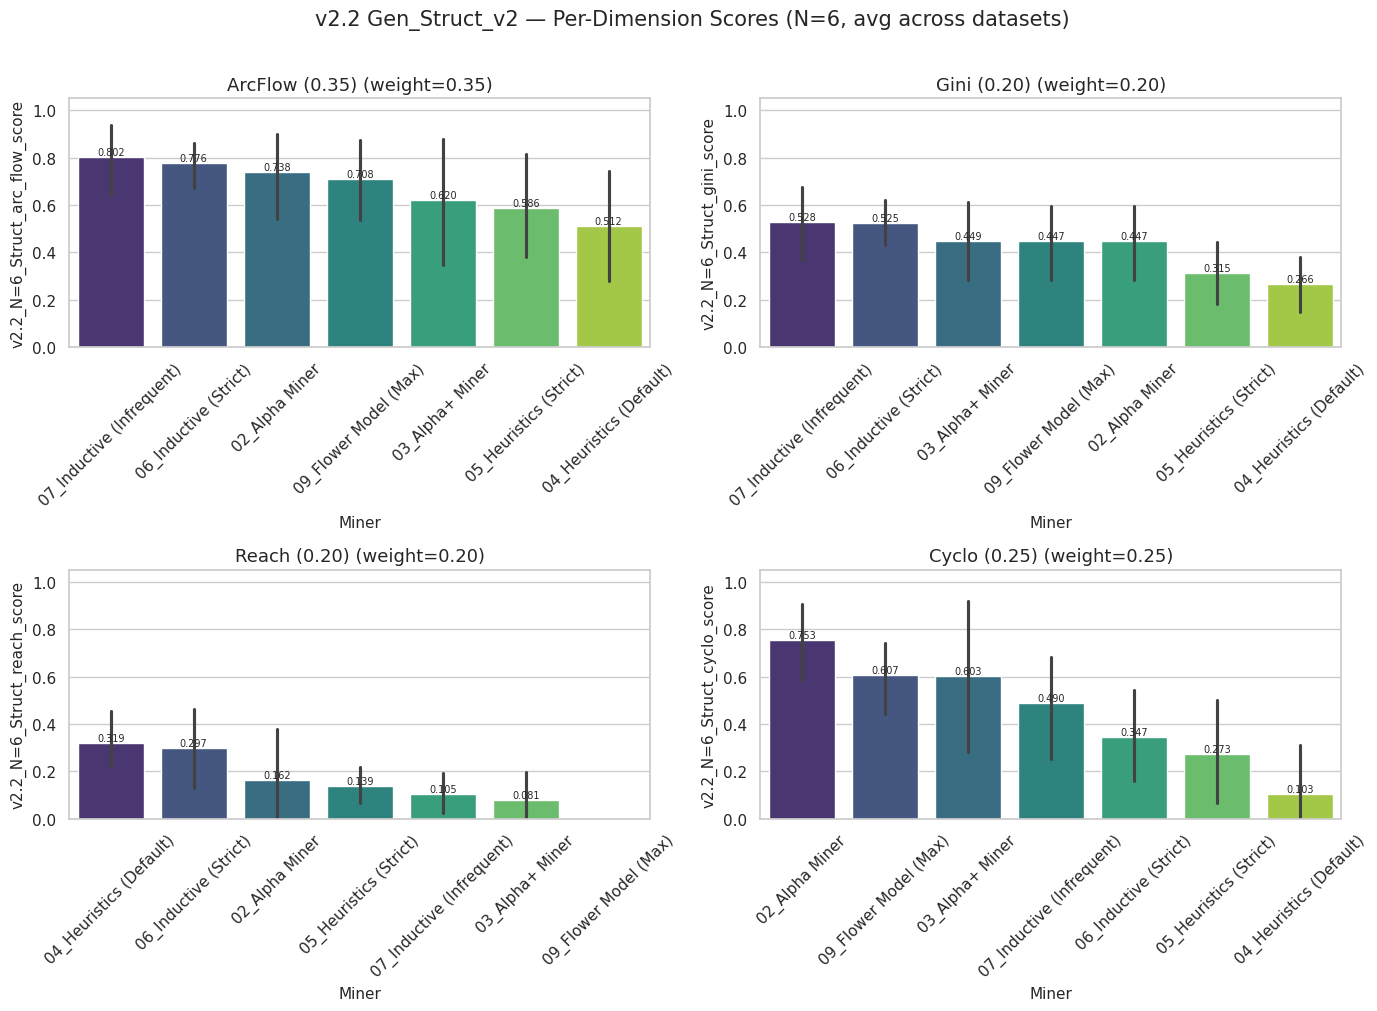

Dimension scores per miner (avg across datasets):


,ArcFlow (0.35),Gini (0.20),Reach (0.20),Cyclo (0.25)
Miner,,,,
02_Alpha Miner,0.738,0.447,0.162,0.753
03_Alpha+ Miner,0.620,0.449,0.081,0.603
04_Heuristics (Default),0.512,0.266,0.319,0.103
05_Heuristics (Strict),0.586,0.315,0.139,0.273
06_Inductive (Strict),0.776,0.525,0.297,0.347
07_Inductive (Infrequent),0.802,0.528,0.105,0.490
09_Flower Model (Max),0.708,0.447,0.000,0.607



Dimension inter-correlation:


,ArcFlow (0.35),Gini (0.20),Reach (0.20),Cyclo (0.25)
ArcFlow (0.35),1.000,0.932,-0.244,0.572
Gini (0.20),0.932,1.000,-0.295,0.610
Reach (0.20),-0.244,-0.295,1.000,-0.673
Cyclo (0.25),0.572,0.610,-0.673,1.000


In [49]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 4: v2.2 GEN_STRUCT COEFFICIENT TUNING             ║
# ║  Recombine arc_flow, gini, reach, cyclo with new weights   ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Cell 10: v2.2 N=6 — per-miner dimension scores ──
DIMS = ['arc_flow_score', 'gini_score', 'reach_score', 'cyclo_score']
DIM_LABELS = ['ArcFlow (0.35)', 'Gini (0.20)', 'Reach (0.20)', 'Cyclo (0.25)']
CURRENT_W = [0.35, 0.20, 0.20, 0.25]
N = '6'  # use N=6

# Extract dimension scores per miner (avg across datasets)
dim_cols = [f'v2.2_N={N}_Struct_{d}' for d in DIMS]
dim_df = df.groupby('Miner')[dim_cols].mean()
dim_df.columns = DIM_LABELS
# Working copy for weight recombination (Cells 11-13)
eval_df = df[['Dataset', 'Miner'] + dim_cols].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (dim, label) in enumerate(zip(DIMS, DIM_LABELS)):
    ax = axes[i // 2, i % 2]
    scores = df[f'v2.2_N={N}_Struct_{dim}']
    # Per-miner distribution
    order = dim_df.sort_values(label, ascending=False).index
    sns.barplot(data=df, x='Miner', y=f'v2.2_N={N}_Struct_{dim}', ax=ax,
                order=order, palette='viridis')
    ax.set_title(f'{label} (weight={CURRENT_W[i]:.2f})')
    ax.set_ylim(0, 1.05); ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0.01:
            ax.annotate(f"{h:.3f}", (p.get_x()+p.get_width()/2.,h), ha='center', va='bottom', fontsize=7)
fig.suptitle('v2.2 Gen_Struct_v2 — Per-Dimension Scores (N=6, avg across datasets)', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Per-miner table
print("Dimension scores per miner (avg across datasets):")
display(dim_df.round(3))

# Correlation between dimensions
print("\nDimension inter-correlation:")
display(dim_df.corr().round(3))

In [50]:
# ── Cell 11: Grid search — maximize structural discrimination ──
from itertools import product

# Objective: maximize Std of Gen_Struct scores across miners (discrimination power)
# Secondary: ensure scores are well-distributed (avoid collapse)

# Grid: step 0.05, each weight ∈ [0.05, 0.85], sum=1.0
step = 0.05
candidates = []
for w1 in np.arange(0.05, 0.90, step):
    for w2 in np.arange(0.05, 0.90, step):
        for w3 in np.arange(0.05, 0.90, step):
            w4 = round(1.0 - w1 - w2 - w3, 2)
            if 0.05 <= w4 <= 0.90:
                candidates.append((round(w1,2), round(w2,2), round(w3,2), w4))

print(f"Testing {len(candidates)} coefficient combinations...")

best_std = -1
best_weights = None
results_list = []

for w in candidates:
    eval_df['_gs'] = (
        w[0] * eval_df[dim_cols[0]] +
        w[1] * eval_df[dim_cols[1]] +
        w[2] * eval_df[dim_cols[2]] +
        w[3] * eval_df[dim_cols[3]]
    )
    
    miner_gs = eval_df.groupby('Miner')['_gs'].mean()
    score_std = miner_gs.std()
    score_spread = miner_gs.max() - miner_gs.min()
    
    results_list.append({
        'w_arc': w[0], 'w_gini': w[1], 'w_reach': w[2], 'w_cyclo': w[3],
        'std': round(score_std, 4),
        'spread': round(score_spread, 4),
    })
    
    if score_std > best_std:
        best_std = score_std
        best_weights = w

results_df = pd.DataFrame(results_list)
print(f"\nBest Std={best_std:.4f} at weights: arc={best_weights[0]:.2f}, gini={best_weights[1]:.2f}, "
      f"reach={best_weights[2]:.2f}, cyclo={best_weights[3]:.2f}")

# Current weights reference
current_mask = ((results_df.w_arc - 0.35).abs() < 0.001) & ((results_df.w_gini - 0.20).abs() < 0.001)
if current_mask.any():
    cur = results_df[current_mask].iloc[0]
    print(f"Current weights (0.35/0.20/0.20/0.25) Std={cur['std']:.4f}, spread={cur['spread']:.4f}")

# Top 10 by Std
print("\nTop 10 coefficient sets by Std:")
display(results_df.sort_values('std', ascending=False).head(10))

# Top 10 by spread
print("\nTop 10 by spread (max−min):")
display(results_df.sort_values('spread', ascending=False).head(10))

Testing 969 coefficient combinations...

Best Std=0.1937 at weights: arc=0.05, gini=0.05, reach=0.05, cyclo=0.85
Current weights (0.35/0.20/0.20/0.25) Std=0.1285, spread=0.3676

Top 10 coefficient sets by Std:


,w_arc,w_gini,w_reach,w_cyclo,std,spread
0,0.05,0.05,0.05,0.85,0.1937,0.5650
153,0.10,0.05,0.05,0.80,0.1858,0.5438
17,0.05,0.10,0.05,0.80,0.1857,0.5416
1,0.05,0.05,0.10,0.80,0.1788,0.5246
289,0.15,0.05,0.05,0.75,0.1780,0.5226
169,0.10,0.10,0.05,0.75,0.1779,0.5204
33,0.05,0.15,0.05,0.75,0.1779,0.5181
154,0.10,0.05,0.10,0.75,0.1710,0.5034
18,0.05,0.10,0.10,0.75,0.1709,0.5012
409,0.20,0.05,0.05,0.70,0.1704,0.5014



Top 10 by spread (max−min):


,w_arc,w_gini,w_reach,w_cyclo,std,spread
0,0.05,0.05,0.05,0.85,0.1937,0.5650
153,0.10,0.05,0.05,0.80,0.1858,0.5438
17,0.05,0.10,0.05,0.80,0.1857,0.5416
1,0.05,0.05,0.10,0.80,0.1788,0.5246
289,0.15,0.05,0.05,0.75,0.1780,0.5226
169,0.10,0.10,0.05,0.75,0.1779,0.5204
33,0.05,0.15,0.05,0.75,0.1779,0.5181
154,0.10,0.05,0.10,0.75,0.1710,0.5034
409,0.20,0.05,0.05,0.70,0.1704,0.5014
18,0.05,0.10,0.10,0.75,0.1709,0.5012


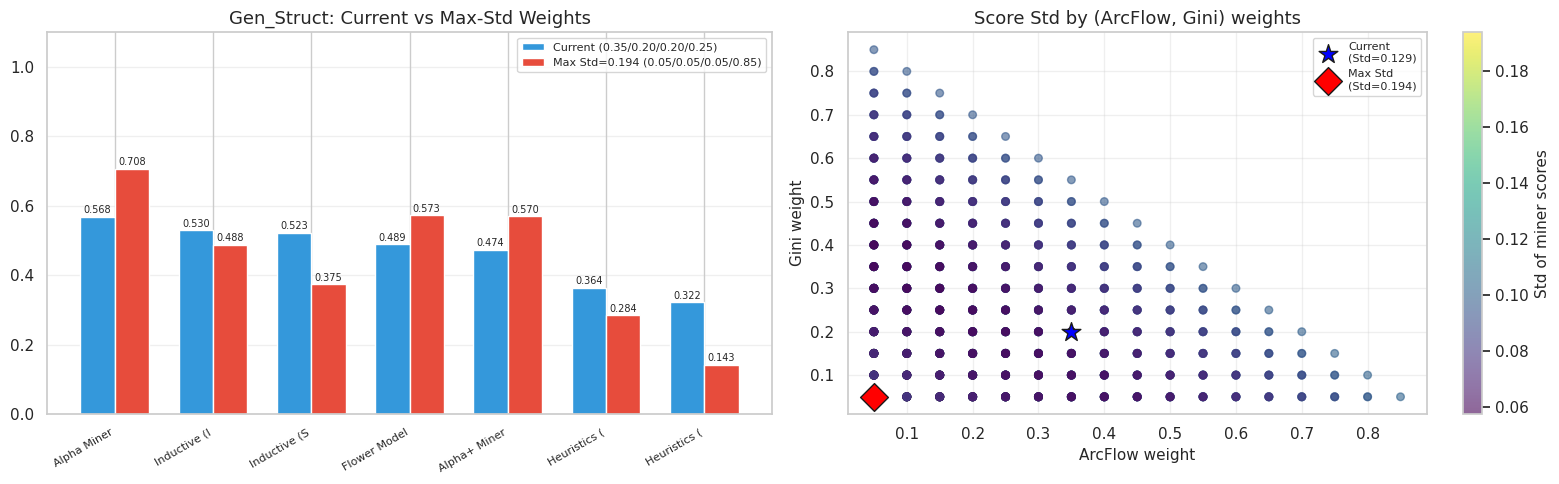

Gen_Struct scores (sorted by current weights descending):


,Current (0.35/0.20/0.20/0.25),Max Std=0.194 (0.05/0.05/0.05/0.85)
Miner,,
02_Alpha Miner,0.568,0.708
07_Inductive (Infrequent),0.530,0.488
06_Inductive (Strict),0.523,0.375
09_Flower Model (Max),0.489,0.573
03_Alpha+ Miner,0.474,0.570
05_Heuristics (Strict),0.364,0.284
04_Heuristics (Default),0.322,0.143



Current Std=0.1285, spread=0.3676
Best Std=0.1937, spread=0.5650

Rankings:


,Current (0.35/0.20/0.20/0.25),Max Std=0.194 (0.05/0.05/0.05/0.85)
Miner,,
02_Alpha Miner,1,1
07_Inductive (Infrequent),2,4
06_Inductive (Strict),3,5
09_Flower Model (Max),4,2
03_Alpha+ Miner,5,3
05_Heuristics (Strict),6,6
04_Heuristics (Default),7,7


In [46]:
# ── Cell 12: Compare current vs max-spread weights — scores & ranking ──
current_w = tuple(CURRENT_W)
best_w = best_weights

miner_scores = {}
for label, w in [('Current (0.35/0.20/0.20/0.25)', current_w),
                  (f'Max Std={best_std:.3f} ({best_w[0]:.2f}/{best_w[1]:.2f}/{best_w[2]:.2f}/{best_w[3]:.2f})', best_w)]:
    eval_df['_tmp'] = (
        w[0] * eval_df[dim_cols[0]] +
        w[1] * eval_df[dim_cols[1]] +
        w[2] * eval_df[dim_cols[2]] +
        w[3] * eval_df[dim_cols[3]]
    )
    miner_scores[label] = eval_df.groupby('Miner')['_tmp'].mean()

comp_df = pd.DataFrame(miner_scores)
comp_df.index.name = 'Miner'
# Sort by current score descending
comp_df = comp_df.sort_values(comp_df.columns[0], ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: side-by-side bar, sorted by current score
x = np.arange(len(comp_df)); w = 0.35
ax1.bar(x - w/2, comp_df.iloc[:, 0], w, label=comp_df.columns[0], color='#3498DB')
ax1.bar(x + w/2, comp_df.iloc[:, 1], w, label=comp_df.columns[1], color='#E74C3C')
for i, (idx, row) in enumerate(comp_df.iterrows()):
    ax1.text(i-w/2, row.iloc[0]+0.01, f"{row.iloc[0]:.3f}", ha='center', fontsize=7)
    ax1.text(i+w/2, row.iloc[1]+0.01, f"{row.iloc[1]:.3f}", ha='center', fontsize=7)
ax1.set_xticks(x)
ax1.set_xticklabels([m.split('_',1)[1][:12] for m in comp_df.index], rotation=30, ha='right', fontsize=8)
ax1.set_title('Gen_Struct: Current vs Max-Std Weights'); ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3, axis='y')

# Right: weight map — where current and best sit
ax = ax2
sc = ax.scatter(results_df['w_arc'], results_df['w_gini'],
                 c=results_df['std'], cmap='viridis', s=30, alpha=0.6)
ax.scatter([0.35], [0.20], c='blue', s=200, marker='*', edgecolors='k',
            label=f'Current\n(Std={cur["std"]:.3f})', zorder=5)
ax.scatter([best_w[0]], [best_w[1]], c='red', s=200, marker='D', edgecolors='k',
            label=f'Max Std\n(Std={best_std:.3f})', zorder=5)
ax.set_xlabel('ArcFlow weight'); ax.set_ylabel('Gini weight')
ax.set_title('Score Std by (ArcFlow, Gini) weights'); ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Std of miner scores')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Print comparison (no assumed ordering)
print("Gen_Struct scores (sorted by current weights descending):")
display(comp_df.round(3))
print(f"\nCurrent Std={cur['std']:.4f}, spread={cur['spread']:.4f}")
print(f"Best Std={best_std:.4f}, spread={results_df.loc[results_df['std'].idxmax(), 'spread']:.4f}")

print("\nRankings:")
rank_comp = comp_df.rank(ascending=False).astype(int)
display(rank_comp)

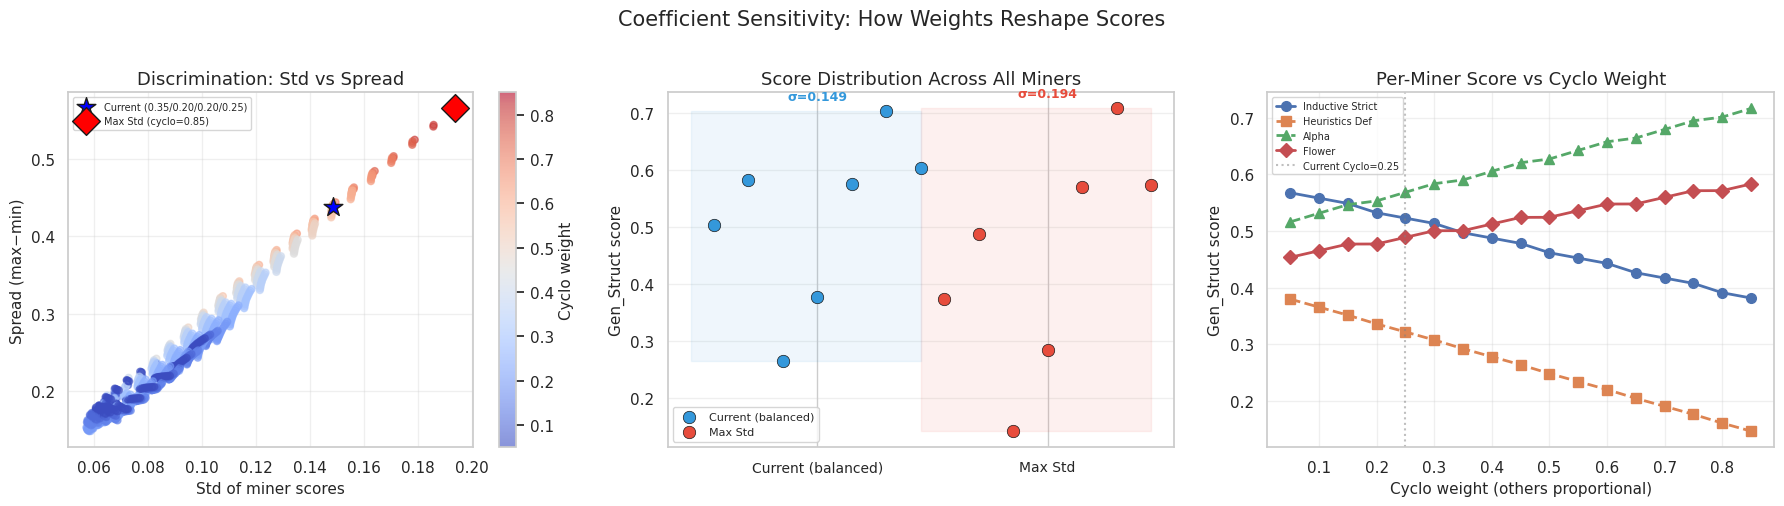

WEIGHT SENSITIVITY SUMMARY
Current (balanced):        Std=0.1487, spread=0.4379
Max Std (cyclo-heavy):     Std=0.1937, spread=0.5650

Current scores: IM=0.503, HM=0.265, Alpha=0.703, Flower=0.604
Max Std scores: IM=0.375, HM=0.143, Alpha=0.708, Flower=0.573

A balanced weight profile preserves multi-dimensional structural awareness.
No single dimension dominates — the score reflects all four structural aspects.


In [47]:
# ── Cell 13: Weight sensitivity — how coefficients affect score distribution ──
ALL_MINERS = ['06_Inductive (Strict)', '07_Inductive (Infrequent)',
              '04_Heuristics (Default)', '05_Heuristics (Strict)',
              '03_Alpha+ Miner', '02_Alpha Miner', '09_Flower Model (Max)']

# For each weight combo, compute: score spread, std, and per-miner scores
sensitivity = []
for _, row in results_df.iterrows():
    w = (row['w_arc'], row['w_gini'], row['w_reach'], row['w_cyclo'])
    eval_df['_tmp'] = (
        w[0] * eval_df[dim_cols[0]] +
        w[1] * eval_df[dim_cols[1]] +
        w[2] * eval_df[dim_cols[2]] +
        w[3] * eval_df[dim_cols[3]]
    )
    miner_gs = eval_df.groupby('Miner')['_tmp'].mean()
    all_scores = miner_gs.reindex(ALL_MINERS)
    
    sensitivity.append({
        'w_arc': w[0], 'w_gini': w[1], 'w_reach': w[2], 'w_cyclo': w[3],
        'spread': round(all_scores.max() - all_scores.min(), 4),
        'std': round(all_scores.std(), 4),
        'IM_score': round(all_scores['06_Inductive (Strict)'], 4) if '06_Inductive (Strict)' in all_scores else None,
        'HM_score': round(all_scores['04_Heuristics (Default)'], 4) if '04_Heuristics (Default)' in all_scores else None,
        'Alpha_score': round(all_scores['02_Alpha Miner'], 4) if '02_Alpha Miner' in all_scores else None,
        'Flower_score': round(all_scores['09_Flower Model (Max)'], 4) if '09_Flower Model (Max)' in all_scores else None,
    })

sens_df = pd.DataFrame(sensitivity)
cur_s = sens_df[(sens_df.w_arc - 0.35).abs() < 0.001].iloc[0] if ((sens_df.w_arc - 0.35).abs() < 0.001).any() else sens_df.iloc[0]
best_s = sens_df.loc[sens_df['std'].idxmax()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Std vs spread
ax = axes[0]
sc = ax.scatter(sens_df['std'], sens_df['spread'],
                c=sens_df['w_cyclo'], cmap='coolwarm', s=25, alpha=0.6)
ax.scatter([cur_s['std']], [cur_s['spread']], c='blue', s=200, marker='*', edgecolors='k', zorder=5,
           label=f'Current (0.35/0.20/0.20/0.25)')
ax.scatter([best_s['std']], [best_s['spread']], c='red', s=200, marker='D', edgecolors='k', zorder=5,
           label=f'Max Std (cyclo={best_s["w_cyclo"]:.2f})')
ax.set_xlabel('Std of miner scores'); ax.set_ylabel('Spread (max−min)')
ax.set_title('Discrimination: Std vs Spread'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Cyclo weight')

# Middle: Score distribution for both profiles
ax = axes[1]
profiles = {
    'Current (balanced)': (cur_s['w_arc'], cur_s['w_gini'], cur_s['w_reach'], cur_s['w_cyclo']),
    'Max Std': (best_s['w_arc'], best_s['w_gini'], best_s['w_reach'], best_s['w_cyclo']),
}
for pi, (pname, pw) in enumerate(profiles.items()):
    eval_df['_tmp'] = (
        pw[0] * eval_df[dim_cols[0]] + pw[1] * eval_df[dim_cols[1]] +
        pw[2] * eval_df[dim_cols[2]] + pw[3] * eval_df[dim_cols[3]]
    )
    scores = eval_df.groupby('Miner')['_tmp'].mean().reindex(ALL_MINERS)
    xs = [pi + 0.15 * mi for mi in range(len(ALL_MINERS))]
    ax.scatter(xs, scores.values, s=80, color=['#3498DB', '#E74C3C'][pi],
               label=pname, zorder=5, edgecolors='k', linewidth=0.5)
    ax.fill_between([pi - 0.1, pi + 0.9], scores.min(), scores.max(),
                    alpha=0.08, color=['#3498DB', '#E74C3C'][pi])
    ax.annotate(f"σ={scores.std():.3f}", (pi + 0.45, scores.max() + 0.02),
                fontsize=9, ha='center', color=['#3498DB', '#E74C3C'][pi], fontweight='bold')

ax.set_xticks([0.45, 1.45])
ax.set_xticklabels(list(profiles.keys()), fontsize=10)
ax.set_ylabel('Gen_Struct score'); ax.set_title('Score Distribution Across All Miners')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Right: Per-miner score vs Cyclo weight
ax = axes[2]
reach_sweep = []
for cw in np.arange(0.05, 0.90, 0.05):
    rem = round(1.0 - cw, 2)
    aw = round(rem * 0.35 / 0.75, 2)
    gw = round(rem * 0.20 / 0.75, 2)
    rw = round(rem - aw - gw, 2)
    if aw < 0.01 or gw < 0.01 or rw < 0.01:
        continue
    eval_df['_tmp'] = aw*eval_df[dim_cols[0]] + gw*eval_df[dim_cols[1]] + rw*eval_df[dim_cols[2]] + cw*eval_df[dim_cols[3]]
    ms = eval_df.groupby('Miner')['_tmp'].mean()
    reach_sweep.append({'w_cyclo': cw,
        'IM': ms.get('06_Inductive (Strict)', np.nan),
        'HM': ms.get('04_Heuristics (Default)', np.nan),
        'Alpha': ms.get('02_Alpha Miner', np.nan),
        'Flower': ms.get('09_Flower Model (Max)', np.nan)})
rs_df = pd.DataFrame(reach_sweep)

for col, style, label in [('IM', 'o-', 'Inductive Strict'), ('HM', 's--', 'Heuristics Def'),
                            ('Alpha', '^--', 'Alpha'), ('Flower', 'D-', 'Flower')]:
    ax.plot(rs_df['w_cyclo'], rs_df[col], style, label=label, linewidth=2, markersize=7)
ax.axvline(x=0.25, color='gray', linestyle=':', alpha=0.5, label='Current Cyclo=0.25')
ax.set_xlabel('Cyclo weight (others proportional)'); ax.set_ylabel('Gen_Struct score')
ax.set_title('Per-Miner Score vs Cyclo Weight'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle('Coefficient Sensitivity: How Weights Reshape Scores', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Summary
print("="*70)
print("WEIGHT SENSITIVITY SUMMARY")
print("="*70)
print(f"Current (balanced):        Std={cur_s['std']:.4f}, spread={cur_s['spread']:.4f}")
print(f"Max Std (cyclo-heavy):     Std={best_s['std']:.4f}, spread={best_s['spread']:.4f}")
print(f"\nCurrent scores: IM={cur_s['IM_score']:.3f}, HM={cur_s['HM_score']:.3f}, "
      f"Alpha={cur_s['Alpha_score']:.3f}, Flower={cur_s['Flower_score']:.3f}")
print(f"Max Std scores: IM={best_s['IM_score']:.3f}, HM={best_s['HM_score']:.3f}, "
      f"Alpha={best_s['Alpha_score']:.3f}, Flower={best_s['Flower_score']:.3f}")
print(f"\nA balanced weight profile preserves multi-dimensional structural awareness.")
print(f"No single dimension dominates — the score reflects all four structural aspects.")